In [2]:
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import threading
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import numpy as np
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy import stats
import random
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
random.seed(42)

In [3]:
df=pd.read_csv('/content/D1_UK_Beans_Brand_PPG.csv')
df.fillna(0,inplace=True)

unique_ppg=df.PPG.unique()
unique_ppg

array(['Others', 'Standard Multi', 'Standard Single', 'Small Single',
       'Small Multi', 'Small SNAP POTS'], dtype=object)

In [4]:
def remove_outliers_iqr(df):

    numeric_cols = df.select_dtypes(include='number').columns
    # numeric_cols=['SalesValue']
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter out outliers for the current column
        df = df[~((df[col] < lower_bound) | (df[col] > upper_bound))]

    return df

# Demand curve PLotting

In [51]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize
import matplotlib.pyplot as plt

def Custom_ridge(df_ch_ppg, transform_function):
    # Original columns in use
    columns_in_use = ['PPL', 'PPL_cann', 'PPL_Comp@Direct', 'PPL_Comp@Indirect', 'D1', 'D1_cann',
                      'D1_Comp@Direct', 'D1_Comp@Indirect', 'Seasonality',
                      'Trend', 'Up_Down_Index', 'Cat_Pr_Index']

    # Apply transformation to the 'PPL' column based on the selected function
    if transform_function == 'reciprocal':
        df_ch_ppg['PPL_transformed'] = 1 / df_ch_ppg['PPL']
    # elif transform_function == 'log':
    #     df_ch_ppg['PPL_transformed'] = np.log(df_ch_ppg['PPL'] + 1)  # Add 1 to avoid log(0)
    elif transform_function == 'exp_neg':
        df_ch_ppg['PPL_transformed'] = np.exp(-df_ch_ppg['PPL'])
    else:  # Default to linear (no transformation)
        df_ch_ppg['PPL_transformed'] = df_ch_ppg['PPL']

    # Replace the original 'PPL' in columns_in_use with 'PPL_transformed'
    columns_in_use[columns_in_use.index('PPL')] = 'PPL_transformed'

    # One-hot encode the 'Brand' column
    df_encoded = pd.get_dummies(df_ch_ppg, columns=['Brand'], drop_first=False)
    df_encoded = df_encoded.replace({True: 1, False: 0})

    # Get unique brand and encoded column names
    unique_brand = df_ch_ppg['Brand'].unique()
    len_unique_brand = len(unique_brand)
    df_encoded_columns = list(df_encoded.columns)
    encoded_columns = df_encoded_columns[-len_unique_brand:]

    # Interaction terms: Multiply transformed PPL with each encoded brand column
    for col in encoded_columns:
        df_encoded[f'PPL_{col}'] = df_encoded['PPL_transformed'] * df_encoded[col]

    # Columns used for modeling (including interaction terms)
    interaction_columns = [f'PPL_{col}' for col in encoded_columns]
    columns_taken = [item for sublist in [columns_in_use, encoded_columns, interaction_columns] for item in sublist]

    # Target variable
    y_var = df_encoded['Volume']
    columns_in_use = columns_in_use

    # Standardize only the 'columns_in_use'
    # scaler = StandardScaler()
    x_var = df_encoded[columns_in_use]
    # x_var_scaled = scaler.fit_transform(x_var)

    # Concatenate the scaled columns with the one-hot and interaction columns
    x_full = df_encoded[columns_taken]
    print(x_full.shape,'>>>>>>>>>>>>>>>>>>>>>>>>>>>')
    # Train-test split
    x_train, x_test, y_train, y_test = train_test_split(x_full, y_var, test_size=0.2, random_state=42)

    # # Adding intercept column to x_train and x_test
    x_train_custom_scaled = x_train
    x_test_custom_scaled = x_test

    # Prediction function (including intercept)
    def predict(X, W):
        output = X.dot(W[1:]) + W[0]
        relu_output = np.maximum(0, output)  # Apply ReLU
        # print(relu_output)
        return output

    # Define the cost function (including L2 regularization)
    def cost_function(params, X, Y, l2_penalty):
        W = params
        Y_pred = predict(X, W)
        cost = np.sum((Y - Y_pred) ** 2) / X.shape[0] + l2_penalty * np.sum(W[1:] ** 2)
        return cost

    # MAPE calculation function
    def mean_absolute_percentage_error(y_true, y_pred):
        y_true = np.where(y_true == 0, np.finfo(float).eps, y_true)
        weighted_mape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)
        return weighted_mape * 100

    # Define constraints based on the problem statement
    def get_constraints(feature_names):
        constraints = [{'type': 'ineq', 'fun': lambda params: -params[1] - 0.01}]
        for i, name in enumerate(feature_names):
            if name in ['D1', 'PPL_Comp@Direct', 'PPL_cann']:
                constraints.append({'type': 'ineq', 'fun': lambda params, i=i: params[i]})
            elif name in ['D1_Comp@Direct', 'D1_cann']:
                constraints.append({'type': 'ineq', 'fun': lambda params, i=i: -params[i] - 0.00001})
        return constraints

    # List of L2 penalty values to iterate over
    l2_penalty_list = [0.01, 0.1, 1, 10, 100]

    # Initialize variables to store the best results
    mape_custom_train_prev = float('inf')
    best_l2_penalty = None
    best_W_opt = None
    best_y_pred_custom_train = None
    best_y_pred_custom_test = None

    for l2_penalty in l2_penalty_list:
        # Initial parameters (weights + intercept)
        initial_params = np.zeros(x_train_custom_scaled.shape[1] + 1)

        # Get the constraints
        constraints = get_constraints(columns_in_use)

        # Minimize the cost function using SLSQP
        result = minimize(
            cost_function,
            initial_params,
            constraints=constraints,
            args=(x_train_custom_scaled, y_train, l2_penalty),
            method='SLSQP'
        )

        # Extract optimized parameters
        W_opt = result.x

        # Make predictions on the training set
        y_pred_custom_train = predict(x_train_custom_scaled, W_opt)
        y_pred_custom_test = predict(x_test_custom_scaled, W_opt)

        # Calculate MAPE for the custom implementation
        mape_custom_train_new = mean_absolute_percentage_error(y_train, y_pred_custom_train)

        # Update the best values if the current MAPE is better
        if mape_custom_train_new < mape_custom_train_prev:
            mape_custom_train_prev = mape_custom_train_new
            best_l2_penalty = l2_penalty
            best_W_opt = W_opt
            best_y_pred_custom_train = y_pred_custom_train
            best_y_pred_custom_test = y_pred_custom_test
            mape_custom_train = mape_custom_train_new  # Update train MAPE
            mape_custom_test = mean_absolute_percentage_error(y_test, y_pred_custom_test)
             # Update test MAPE

    # Report the final results
    print(f'Best l2_penalty: {best_l2_penalty}')
    print(f'MAPE (Train): {mape_custom_train:.2f}%')
    print(f'MAPE (Test): {mape_custom_test:.2f}%')
    # Function to plot the demand curve
    # demand_predicted = x_full.dot(best_W_opt)
    print(transform_function,'Tranformation')
    def plot_demand_curve(x_full, best_W_opt, transform_function):
        # Generate a range of PPL values to simulate different demand scenarios
        if transform_function == 'reciprocal':
            PPL_values = np.linspace(0.1, 2.0, 100)  # Avoid zero to prevent division errors
            PPL_transformed = 1 / PPL_values

        elif transform_function == 'exp_neg':
            PPL_values = np.linspace(0, 10, 100)
            PPL_transformed = np.exp(-PPL_values)
        else:  # Default linear transformation
            PPL_values = np.linspace(0, 10, 100)
            PPL_transformed = PPL_values

        # Get weight for PPL (price-related term)
        W_opt_demand_curve = best_W_opt[1:].copy()
        W_opt_demand_curve[0] = 0  # Ignore intercept for demand calculation with PPL effect

        # Predict demand as a function of price
        mean_all = np.mean(x_full.dot(W_opt_demand_curve))
        demand = best_W_opt[0] + mean_all +  PPL_transformed* best_W_opt[1]

        # Clamp demand to ensure it is non-negative
        demand = np.maximum(demand, 0)

        # Calculate the price at which demand is zero
        zero_demand_price = -(best_W_opt[0]+mean_all) / best_W_opt[1] if best_W_opt[1] != 0 else None

        # Plot demand curve
        plt.plot( demand,PPL_values, label=f'Demand Curve ({transform_function} transformation)')
        plt.xlabel('Predicted Demand (Volume)')
        plt.ylabel('Price (PPL)')
        plt.legend()
        plt.title('Demand Curve')

        # # Mark the zero-demand price point on the graph, if applicable
        # if zero_demand_price and zero_demand_price > 0:
        #     plt.axvline(x=zero_demand_price, color='red', linestyle='--', label=f'Demand=0 at PPL={zero_demand_price:.2f}')
        #     plt.legend()

        # plt.show()
        # print(f"Price at which demand reaches zero: {np.abs(zero_demand_price)}")
        # return zero_demand_price
    # Call plot_demand_curve with modified parameters
    zero_demand_price=plot_demand_curve(x_full, best_W_opt, transform_function)
    # Optionally, you can plot the results using the best test predictions
    plt.figure(figsize=(16, 6))
    x_value = [i + 1 for i in range(len(y_test))]
    plt.plot(x_value, y_test, label='Actual Values', marker='o')
    plt.plot(x_value, best_y_pred_custom_test, label='Predicted Values by Custom Code', marker='x')

    # Adding title and labels
    plt.title(f'Actual vs Predicted Values (Best l2_penalty={best_l2_penalty})')
    plt.xlabel('Index')
    plt.ylabel('Values')
    plt.xticks(rotation=90)
    plt.legend()
    plt.show()

    return mape_custom_train, mape_custom_test, best_W_opt,zero_demand_price

In [52]:
unique_channel=df.Channel.unique()
# unique_channel=['Supermarkets']
channel=[]
ppg_list=[]
unique_brand_list=[]
train_mape=[]
test_mape=[]
zero_demand_list=[]
for ch in unique_channel:
  df_ch=df[df['Channel']==ch]

  unique_ppg=df_ch.PPG.unique()
  # unique_ppg=['Standard Multi']
  for ppg in unique_ppg:
    df_ch_ppg=df_ch[df_ch['PPG']==ppg]
    unique_brand=df_ch_ppg.Brand.unique()


    df_ch_ppg=df_ch_ppg[['Market', 'Channel', 'Region', 'Category', 'SubCategory', 'Brand',
          'Variant', 'PackType', 'PPG', 'PackSize', 'Year',
          'Month', 'Week', 'Date', 'SalesValue', 'Volume', 'VolumeUnits', 'D1',
          'PPU', 'PPL', 'Cat_Vol_all_Chn', 'Cat_Vol_in_Chn', 'Seasonality',
          'Trend', 'Cat_Sales_in_Chn', 'Volume_sum_cann', 'D1_cann',
          'D1_Comp@Direct', 'D1_Comp@Indirect', 'PPU_cann', 'PPU_Comp@Direct',
          'PPU_Comp@Indirect', 'PPL_cann', 'PPL_Comp@Direct', 'PPL_Comp@Indirect',
          'Up_Down_Index', 'Cat_Pr_Index']]

    df_ch_ppg.dropna(inplace=True)
    df_ch_ppg.reset_index(drop=True,inplace=True)
    # df_ch_ppg=remove_outliers_iqr(df_ch_ppg)
    if len(df_ch_ppg)>30:


      print(f'enough data points( {len(df_ch_ppg)}   ) for combination of Channel>>> {ch} and PPG >>> {ppg} and available brands are {unique_brand} ')
      transform_function='linear'
      mape_train,mape_test,opt_w,zero_demand_price=Custom_ridge(df_ch_ppg, transform_function)
      # print(len(opt_w))
      # price_coef_index=1
      # price_range=[0,10]

      channel.append(ch)
      ppg_list.append(ppg)
      train_mape.append(mape_train)
      test_mape.append(mape_test)
      unique_brand_list.append(unique_brand)
      zero_demand_list.append(zero_demand_price)


    else :
      print(f'not enough data points ( {len(df_ch_ppg)}   ) for combination of Channel>>> {ch} and PPG >>> {ppg} and available brands are {unique_brand} ')

Output hidden; open in https://colab.research.google.com to view.

In [6]:
result_df=pd.DataFrame({'Channel':channel,'PPG':ppg_list,'Brands':unique_brand_list,'Train_MAPE':train_mape,'Test_MAPE':test_mape})

result_df['Train_MAPE']=result_df['Train_MAPE'].round(2)
result_df['Test_MAPE']=result_df['Test_MAPE'].round(2)
result_df

,Channel,PPG,Brands,Train_MAPE,Test_MAPE
0,Convenience,Others,"[BRANSTON, HEINZ Standard, Restofcategory]",29.67,34.09
1,Convenience,Standard Multi,"[BRANSTON, HEINZ Standard, Private Label Std]",35.43,35.69
2,Convenience,Standard Single,"[BRANSTON, HEINZ Flavoured, HEINZ Standard, Pr...",20.53,20.67
3,Convenience,Small Single,"[HEINZ Flavoured, HEINZ Standard, Private Labe...",23.28,23.56
4,Convenience,Small Multi,[HEINZ Standard],23.43,25.93
5,Convenience,Small SNAP POTS,[HEINZ Standard],18.45,20.14
6,Iceland,Small Multi,"[BRANSTON, HEINZ Standard]",31.68,24.86
7,Iceland,Small Single,"[BRANSTON, HEINZ Flavoured, HEINZ Standard, Pr...",49.50,67.47
8,Iceland,Standard Multi,"[BRANSTON, HEINZ Standard]",17.20,16.42
9,Iceland,Standard Single,"[BRANSTON, HEINZ Flavoured, HEINZ Standard, Re...",42.67,47.08


# Brand Wise Mape and best Transformation

In [49]:
def Custom_ridge(df_ch_ppg, transform_function='exp_neg'):
    # Original columns in use
    columns_in_use = ['PPL', 'PPL_cann', 'PPL_Comp@Direct', 'PPL_Comp@Indirect', 'D1', 'D1_cann',
                      'D1_Comp@Direct', 'D1_Comp@Indirect', 'Seasonality',
                      'Trend', 'Up_Down_Index', 'Cat_Pr_Index']

    # Apply transformation to the 'PPL' column based on the selected function
    if transform_function == 'reciprocal':
        df_ch_ppg['PPL_transformed'] = 1 / df_ch_ppg['PPL']
    elif transform_function == 'log':
        df_ch_ppg['PPL_transformed'] = np.log(df_ch_ppg['PPL'] + 1)
    elif transform_function == 'exp_neg':
        df_ch_ppg['PPL_transformed'] = np.exp(-df_ch_ppg['PPL'])
    else:
        df_ch_ppg['PPL_transformed'] = df_ch_ppg['PPL']

    # Replace the original 'PPL' in columns_in_use with 'PPL_transformed'
    columns_in_use[columns_in_use.index('PPL')] = 'PPL_transformed'

    # One-hot encode the 'Brand' column
    df_encoded = pd.get_dummies(df_ch_ppg, columns=['Brand'], drop_first=False)
    df_encoded = df_encoded.replace({True: 1, False: 0})

    # Get unique brand and encoded column names
    unique_brands = df_ch_ppg['Brand'].unique()
    encoded_columns = [f'Brand_{brand}' for brand in unique_brands]

    # Interaction terms: Multiply transformed PPL with each encoded brand column
    for col in encoded_columns:
        df_encoded[f'PPL_{col}'] = df_encoded['PPL_transformed'] * df_encoded[col]

    # Columns used for modeling (including interaction terms)
    interaction_columns = [f'PPL_{col}' for col in encoded_columns]
    columns_in_use += interaction_columns

    # Target variable
    y_var = df_encoded['Volume']

    # Standardize only the 'columns_in_use'
    scaler = StandardScaler()
    x_var = df_encoded[columns_in_use]
    x_var_scaled = scaler.fit_transform(x_var)

    # Train-test split
    x_train, x_test, y_train, y_test = train_test_split(x_var_scaled, y_var, test_size=0.2, random_state=42)

    # # Prediction function
    # def predict(X, W):
    # #     print(X.dot(W[1:]) + W[0])
    #    return X.dot(W[1:]) + W[0]
    def predict(X, W):
        output = X.dot(W[1:]) + W[0]
        relu_output = np.maximum(0, output)  # Apply ReLU
        # print(relu_output)
        return output

    # Define cost function with L2 regularization
    def cost_function(params, X, Y, l2_penalty):
        W = params
        Y_pred = predict(X, W)
        cost = np.sum((Y - Y_pred) ** 2) / X.shape[0] + l2_penalty * np.sum(W[1:] ** 2)
        return cost
    def percentage(y_true, y_pred):
        y_true = np.where(y_true == 0, np.finfo(float).eps, y_true)
        percentage_error = (np.abs((y_true - y_pred) / y_true)) * 100
        return percentage_error
    # # Calculate MAPE
    # def mean_absolute_percentage_error(y_true, y_pred):
    #     y_true = np.where(y_true == 0, np.finfo(float).eps, y_true)

    #     weighted_mape = np.sum(percentage(y_true,y_pred)*y_true) / np.sum(y_true)
    #     return weighted_mape
    # MAPE calculation function
    def mean_absolute_percentage_error(y_true, y_pred):
        y_true = np.where(y_true == 0, np.finfo(float).eps, y_true)
        weighted_mape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)
        return weighted_mape * 100

    # Constraints for optimization
    def get_constraints(feature_names):
        constraints = [{'type': 'ineq', 'fun': lambda params: -params[1] - 0.01}]
        for i, name in enumerate(feature_names):
            if name in ['D1', 'PPL_Comp@Direct', 'PPL_cann']:
                constraints.append({'type': 'ineq', 'fun': lambda params, i=i: params[i]})
            elif name in ['D1_Comp@Direct', 'D1_cann']:
                constraints.append({'type': 'ineq', 'fun': lambda params, i=i: -params[i] - 0.00001})
        return constraints


    # L2 penalty values
    l2_penalty_list = [0.01, 0.1, 1, 10, 100]
    best_mape, best_W_opt = float('inf'), None
    mape_custom_train_prev = float('inf')
    if transform_function == 'linear':
        # for l2_penalty in l2_penalty_list:
        #   # Initial parameters (weights + intercept)
        #   initial_params = np.zeros(x_train.shape[1] + 1)

        #   # Get the constraints
        #   constraints = get_constraints(columns_in_use)

        #   # Minimize the cost function using SLSQP
        #   result = minimize(
        #       cost_function,
        #       initial_params,
        #       args=(x_train, y_train, l2_penalty),
        #       constraints=constraints,
        #       method='SLSQP'
        #   )

        #   # Extract optimized parameters
        #   W_opt = result.x
        #   y_pred_train = predict(x_train, W_opt)
        #   mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
        #   if mape_train < best_mape:
        #       best_mape, best_W_opt = mape_train, W_opt

        for l2_penalty in l2_penalty_list:
          # Initial parameters (weights + intercept)
          initial_params = np.zeros(x_train.shape[1] + 1)

          # Get the constraints
          constraints = get_constraints(columns_in_use)

          # Minimize the cost function using SLSQP
          result = minimize(
              cost_function,
              initial_params,
              constraints=constraints,
              args=(x_train, y_train, l2_penalty),
              method='SLSQP'
          )

          # Extract optimized parameters
          W_opt = result.x

          # Make predictions on the training set
          y_pred_custom_train = predict(x_train, W_opt)
          y_pred_custom_test = predict(x_test, W_opt)

          # Calculate MAPE for the custom implementation
          mape_custom_train_new = mean_absolute_percentage_error(y_train, y_pred_custom_train)

          # Update the best values if the current MAPE is better
          if mape_custom_train_new < mape_custom_train_prev:
              mape_custom_train_prev = mape_custom_train_new
              best_l2_penalty = l2_penalty
              best_W_opt = W_opt
              best_y_pred_custom_train = y_pred_custom_train
              best_y_pred_custom_test = y_pred_custom_test
              mape_custom_train = mape_custom_train_new  # Update train MAPE
              mape_custom_test = mean_absolute_percentage_error(y_test, y_pred_custom_test)
              best_mape, best_W_opt = mape_custom_train, best_W_opt # Update test MAPE
              print(best_mape,l2_penalty,">>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>")
    else:
        for l2_penalty in l2_penalty_list:
            initial_params = np.zeros(x_train.shape[1] + 1)
            constraints = get_constraints(columns_in_use)
            result = minimize(cost_function, initial_params, args=(x_train, y_train, l2_penalty), method='SLSQP')
            W_opt = result.x
            y_pred_train = predict(x_train, W_opt)
            mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
            if mape_train < best_mape:
                best_mape, best_W_opt = mape_train, W_opt

    # Calculate overall test MAPE
    y_pred_test = predict(x_test, best_W_opt)
    overall_mape_test = mean_absolute_percentage_error(y_test, y_pred_test)

    # Calculate MAPE for each brand
    brand_mapes = {}
    for brand, col_name in zip(unique_brands, encoded_columns):
        brand_indices = df_encoded[df_encoded[col_name] == 1].index
        x_brand = x_var_scaled[brand_indices]
        y_brand = y_var.iloc[brand_indices]
        y_pred_brand = predict(x_brand, best_W_opt)
        brand_mapes[brand] = mean_absolute_percentage_error(y_brand, y_pred_brand)

    # Print final results
    print(f'Best L2 Penalty: {l2_penalty_list[np.argmin(brand_mapes)]}')
    print(f'Overall MAPE (Test): {overall_mape_test:.2f}%')
    print("Brand-wise MAPE:", brand_mapes)

    return best_mape, overall_mape_test, best_W_opt, brand_mapes

In [50]:
# Initialize lists for storing the expanded data
channel_list = []
ppg_list = []
brand_list = []
train_mape_list = []
test_mape_list = []
brand_list_unique = []
brand_mape_list=[]
index_list=[]
# Iterate over each unique channel
for ch in unique_channel:
    df_ch = df[df['Channel'] == ch]
    unique_ppg = df_ch.PPG.unique()

    # Iterate over each unique PPG within the current channel
    for ppg in unique_ppg:
        df_ch_ppg = df_ch[df_ch['PPG'] == ppg]
        unique_brands = df_ch_ppg.Brand.unique()

        # Filter relevant columns and clean up data
        df_ch_ppg = df_ch_ppg[['Market', 'Channel', 'Region', 'Category', 'SubCategory', 'Brand',
                               'Variant', 'PackType', 'PPG', 'PackSize', 'Year', 'Month', 'Week',
                               'Date', 'SalesValue', 'Volume', 'VolumeUnits', 'D1', 'PPU', 'PPL',
                               'Cat_Vol_all_Chn', 'Cat_Vol_in_Chn', 'Seasonality', 'Trend',
                               'Cat_Sales_in_Chn', 'Volume_sum_cann', 'D1_cann', 'D1_Comp@Direct',
                               'D1_Comp@Indirect', 'PPU_cann', 'PPU_Comp@Direct', 'PPU_Comp@Indirect',
                               'PPL_cann', 'PPL_Comp@Direct', 'PPL_Comp@Indirect', 'Up_Down_Index',
                               'Cat_Pr_Index']]

        df_ch_ppg.dropna(inplace=True)
        df_ch_ppg.reset_index(drop=True, inplace=True)

        # Only proceed if there are enough data points
        if len(df_ch_ppg) > 30:
            print(f'enough data points ({len(df_ch_ppg)}) for combination of Channel>>> {ch} and PPG >>> {ppg} and available brands are {unique_brands}')

            # Compute MAPE and zero demand price using the custom function
            list_mape_train=[]
            function_list=['linear']
            for trans in function_list:

              mape_train, mape_test, opt_w, brand_wise_mape = Custom_ridge(df_ch_ppg, transform_function=trans)
              list_mape_train.append([mape_train,mape_test,opt_w,brand_wise_mape])
              # print(brand_wise_mape)
            min_index = min(range(len(list_mape_train)), key=lambda i: list_mape_train[i][0])

            # Get the complete list with the minimum first element
            min_list = list_mape_train[min_index]
            brand_wise_mape=min_list[3]
            mape_train=min_list[0]
            mape_test=min_list[1]
            print(mape_train,mape_test)
            for key, value in brand_wise_mape.items():
                  brand_list_unique.append(key)
                  brand_mape_list.append(value)
            # Store values for each brand

                  channel_list.append(ch)
                  ppg_list.append(ppg)
                  brand_list.append(unique_brands)
                  train_mape_list.append(mape_train)  # Get train MAPE for brand
                  test_mape_list.append(mape_test)
                  index_list.append(function_list[min_index])# Get test MAPE for brand


        else:
              print(f'not enough data points ({len(df_ch_ppg)}) for combination of Channel>>> {ch} and PPG >>> {ppg} and available brands are {unique_brands}')





enough data points (255) for combination of Channel>>> Convenience and PPG >>> Others and available brands are ['BRANSTON' 'HEINZ Standard' 'Restofcategory']
30.45131068050845 0.01 >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Best L2 Penalty: 0.01
Overall MAPE (Test): 34.03%
Brand-wise MAPE: {'BRANSTON': 45.781000466630566, 'HEINZ Standard': 24.447337651861222, 'Restofcategory': 84.12431410628287}
30.45131068050845 34.02759163381756
enough data points (492) for combination of Channel>>> Convenience and PPG >>> Standard Multi and available brands are ['BRANSTON' 'HEINZ Standard' 'Private Label Std']
27.583439493676593 0.01 >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Best L2 Penalty: 0.01
Overall MAPE (Test): 31.12%
Brand-wise MAPE: {'BRANSTON': 29.574819496870315, 'HEINZ Standard': 17.414238966882838, 'Private Label Std': 130.08338235004751}
27.583439493676593 31.117362833126798
enough data points (817) for combination o

In [9]:
# Create the final DataFrame with the required columns
result_df = pd.DataFrame({
    'Channel': channel_list,
    'PPG': ppg_list,
    'Unique_Brands': brand_list,
    'Train_MAPE': train_mape_list,
    'Test_MAPE': test_mape_list,
    'Brand': brand_list_unique,
    'Brand_mape': brand_mape_list,
    'Best_transformation':index_list
})

# Round MAPE columns to two decimal places
result_df['Train_MAPE'] = result_df['Train_MAPE'].round(2)
result_df['Test_MAPE'] = result_df['Test_MAPE'].round(2)
result_df['Brand_mape'] = result_df['Brand_mape'].round(2)

In [10]:
result_df

,Channel,PPG,Unique_Brands,Train_MAPE,Test_MAPE,Brand,Brand_mape,Best_transformation
0,Convenience,Others,"[BRANSTON, HEINZ Standard, Restofcategory]",44.03,55.96,BRANSTON,41.64,linear
1,Convenience,Others,"[BRANSTON, HEINZ Standard, Restofcategory]",44.03,55.96,HEINZ Standard,38.59,linear
2,Convenience,Others,"[BRANSTON, HEINZ Standard, Restofcategory]",44.03,55.96,Restofcategory,151.75,linear
3,Convenience,Standard Multi,"[BRANSTON, HEINZ Standard, Private Label Std]",26.88,27.99,BRANSTON,32.72,linear
4,Convenience,Standard Multi,"[BRANSTON, HEINZ Standard, Private Label Std]",26.88,27.99,HEINZ Standard,16.97,linear
...,...,...,...,...,...,...,...,...
66,Tesco,Standard Single,"[BRANSTON, HEINZ Flavoured, HEINZ Standard, Pr...",26.54,26.41,Private Label Value,71.29,linear
67,Tesco,Standard Single,"[BRANSTON, HEINZ Flavoured, HEINZ Standard, Pr...",26.54,26.41,Restofcategory,2461460.54,linear
68,Tesco,Others,[HEINZ Standard],17.31,14.51,HEINZ Standard,16.72,linear
69,Tesco,Small Multi,[HEINZ Standard],26.52,23.92,HEINZ Standard,26.02,linear


# Relative Price Approach

In [26]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize
import matplotlib.pyplot as plt

def Custom_ridge(df_ch_ppg, transform_function):
    # Original columns in use
    columns_in_use = ['PPL', 'PPL_cann', 'PPL_Comp@Direct', 'PPL_Comp@Indirect', 'D1', 'D1_cann',
                      'D1_Comp@Direct', 'D1_Comp@Indirect', 'Seasonality',
                      'Trend', 'Up_Down_Index', 'Cat_Pr_Index']

    # Apply transformation to the 'PPL' column based on the selected function
    if transform_function == 'reciprocal':
        df_ch_ppg['PPL_transformed'] = 1 / df_ch_ppg['PPL']
    # elif transform_function == 'log':
    #     df_ch_ppg['PPL_transformed'] = np.log(df_ch_ppg['PPL'] + 1)  # Add 1 to avoid log(0)
    elif transform_function == 'exp_neg':
        df_ch_ppg['PPL_transformed'] = np.exp(-df_ch_ppg['PPL'])
    else:  # Default to linear (no transformation)
        df_ch_ppg['PPL_transformed'] = df_ch_ppg['PPL']

    # Replace the original 'PPL' in columns_in_use with 'PPL_transformed'
    columns_in_use[columns_in_use.index('PPL')] = 'PPL_transformed'

    # One-hot encode the 'Brand' column
    df_encoded = pd.get_dummies(df_ch_ppg, columns=['Brand'], drop_first=False)
    df_encoded = df_encoded.replace({True: 1, False: 0})
    relative_pr=['PPL_cann', 'PPL_Comp@Direct', 'PPL_Comp@Indirect']
    for col in relative_pr:
      df_encoded[col] = np.where(
          df_encoded[col] == 0,  # Condition: if the column value is 0
          df_encoded[col],       # Keep it the same (unchanged)
          df_encoded['PPL_transformed'] / df_encoded[col]  # Else: compute the ratio
      )


    # Get unique brand and encoded column names
    unique_brand = df_ch_ppg['Brand'].unique()
    len_unique_brand = len(unique_brand)
    df_encoded_columns = list(df_encoded.columns)
    encoded_columns = df_encoded_columns[-len_unique_brand:]

    # Interaction terms: Multiply transformed PPL with each encoded brand column
    for col in encoded_columns:
        df_encoded[f'PPL_{col}'] = df_encoded['PPL_transformed'] * df_encoded[col]

    # Columns used for modeling (including interaction terms)
    interaction_columns = [f'PPL_{col}' for col in encoded_columns]
    columns_taken = [item for sublist in [columns_in_use, encoded_columns, interaction_columns] for item in sublist]

    # Target variable
    y_var = df_encoded['Volume']
    columns_in_use = columns_in_use

    # Standardize only the 'columns_in_use'
    scaler = StandardScaler()
    x_var = df_encoded[columns_in_use]
    x_var_scaled = scaler.fit_transform(x_var)

    # Concatenate the scaled columns with the one-hot and interaction columns
    x_full = np.concatenate([x_var_scaled, df_encoded[encoded_columns + interaction_columns].values], axis=1)
    print(x_full.shape,'>>>>>>>>>>>>>>>>>>>>>>>>>>>')
    # Train-test split
    x_train, x_test, y_train, y_test = train_test_split(x_full, y_var, test_size=0.2, random_state=42)

    # # Adding intercept column to x_train and x_test
    x_train_custom_scaled = x_train
    x_test_custom_scaled = x_test

    # Prediction function (including intercept)
    def predict(X, W):
        output = X.dot(W[1:]) + W[0]
        relu_output = np.maximum(0, output)  # Apply ReLU
        # print(relu_output)
        return relu_output

    # Define the cost function (including L2 regularization)
    def cost_function(params, X, Y, l2_penalty):
        W = params
        Y_pred = predict(X, W)
        cost = np.sum((Y - Y_pred) ** 2) / X.shape[0] + l2_penalty * np.sum(W[1:] ** 2)
        return cost

    # MAPE calculation function
    def mean_absolute_percentage_error(y_true, y_pred):
        y_true = np.where(y_true == 0, np.finfo(float).eps, y_true)
        weighted_mape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)
        return weighted_mape * 100

    # Define constraints based on the problem statement
    def get_constraints(feature_names):
        constraints = [{'type': 'ineq', 'fun': lambda params: -params[1] - 0.01}]
        constraints=[{'type': 'ineq', 'fun': lambda params: params[2] }]
        constraints=[{'type': 'ineq', 'fun': lambda params: params[3] }]
        constraints=[{'type': 'ineq', 'fun': lambda params: params[4] }]
        for i, name in enumerate(feature_names):
            if name in ['D1', 'PPL_Comp@Direct', 'PPL_cann']:
                constraints.append({'type': 'ineq', 'fun': lambda params, i=i: params[i]})
            elif name in ['D1_Comp@Direct', 'D1_cann']:
                constraints.append({'type': 'ineq', 'fun': lambda params, i=i: -params[i] - 0.00001})
        return constraints

    # List of L2 penalty values to iterate over
    l2_penalty_list = [0.01, 0.1, 1, 10, 100]

    # Initialize variables to store the best results
    mape_custom_train_prev = float('inf')
    best_l2_penalty = None
    best_W_opt = None
    best_y_pred_custom_train = None
    best_y_pred_custom_test = None

    for l2_penalty in l2_penalty_list:
        # Initial parameters (weights + intercept)
        initial_params = np.zeros(x_train_custom_scaled.shape[1] + 1)

        # Get the constraints
        constraints = get_constraints(columns_in_use)

        # Minimize the cost function using SLSQP
        result = minimize(
            cost_function,
            initial_params,
            constraints=constraints,
            args=(x_train_custom_scaled, y_train, l2_penalty),
            method='SLSQP'
        )

        # Extract optimized parameters
        W_opt = result.x

        # Make predictions on the training set
        y_pred_custom_train = predict(x_train_custom_scaled, W_opt)
        y_pred_custom_test = predict(x_test_custom_scaled, W_opt)

        # Calculate MAPE for the custom implementation
        mape_custom_train_new = mean_absolute_percentage_error(y_train, y_pred_custom_train)

        # Update the best values if the current MAPE is better
        if mape_custom_train_new < mape_custom_train_prev:
            mape_custom_train_prev = mape_custom_train_new
            best_l2_penalty = l2_penalty
            best_W_opt = W_opt
            best_y_pred_custom_train = y_pred_custom_train
            best_y_pred_custom_test = y_pred_custom_test
            mape_custom_train = mape_custom_train_new  # Update train MAPE
            mape_custom_test = mean_absolute_percentage_error(y_test, y_pred_custom_test)
             # Update test MAPE

    # Report the final results
    print(f'Best l2_penalty: {best_l2_penalty}')
    print(f'MAPE (Train): {mape_custom_train:.2f}%')
    print(f'MAPE (Test): {mape_custom_test:.2f}%')
    # Function to plot the demand curve
    # demand_predicted = x_full.dot(best_W_opt)
    print(transform_function,'Tranformation')
    def plot_demand_curve(x_full, best_W_opt, transform_function, scaler):
        # Generate a range of PPL values to simulate different demand scenarios
        if transform_function == 'reciprocal':
            PPL_values = np.linspace(0.1, 2.0, 100)  # Avoid zero to prevent division errors
            PPL_transformed = 1 / PPL_values

        elif transform_function == 'exp_neg':
            PPL_values = np.linspace(0, 10, 100)
            PPL_transformed = np.exp(-PPL_values)
        else:  # Default linear transformation
            PPL_values = np.linspace(0, 10, 100)
            PPL_transformed = PPL_values

        # Get weight for PPL (price-related term)

        W_opt_demand_curve = best_W_opt[1:].copy()

        W_opt_demand_curve[0] = 0
        W_opt_demand_curve[1] = 0
        W_opt_demand_curve[2] = 0
        W_opt_demand_curve[3] = 0
        # W_opt_demand_curve[] = 0          # Ignore intercept for demand calculation with PPL effect

        # Predict demand as a function of price

        mean_all = np.mean(x_full.dot(W_opt_demand_curve))
        demand = best_W_opt[0] + mean_all +  best_W_opt[1]+

    #     # Clamp demand to ensure it is non-negative
    #     demand = np.maximum(demand, 0)

    #     # Calculate the price at which demand is zero
    #     zero_demand_price = -(best_W_opt[0]+mean_all) / best_W_opt[1] if best_W_opt[1] != 0 else None

    #     # Plot demand curve
    #     plt.plot( demand,PPL_values, label=f'Demand Curve ({transform_function} transformation)')
    #     plt.xlabel('Predicted Demand (Volume)')
    #     plt.ylabel('Price (PPL)')
    #     plt.legend()
    #     plt.title('Demand Curve')

    #     # # Mark the zero-demand price point on the graph, if applicable
    #     # if zero_demand_price and zero_demand_price > 0:
    #     #     plt.axvline(x=zero_demand_price, color='red', linestyle='--', label=f'Demand=0 at PPL={zero_demand_price:.2f}')
    #     #     plt.legend()

    #     # plt.show()
    #     # print(f"Price at which demand reaches zero: {np.abs(zero_demand_price)}")
    #     # return zero_demand_price
    # # Call plot_demand_curve with modified parameters
    # zero_demand_price=plot_demand_curve(x_full, best_W_opt, transform_function, scaler)
    # # Optionally, you can plot the results using the best test predictions
    # plt.figure(figsize=(16, 6))
    # x_value = [i + 1 for i in range(len(y_test))]
    # plt.plot(x_value, y_test, label='Actual Values', marker='o')
    # plt.plot(x_value, best_y_pred_custom_test, label='Predicted Values by Custom Code', marker='x')

    # # Adding title and labels
    # plt.title(f'Actual vs Predicted Values (Best l2_penalty={best_l2_penalty})')
    # plt.xlabel('Index')
    # plt.ylabel('Values')
    # plt.xticks(rotation=90)
    # plt.legend()
    # plt.show()


    return mape_custom_train, mape_custom_test, best_W_opt,zero_demand_price

enough data points( 255   ) for combination of Channel>>> Convenience and PPG >>> Others and available brands are ['BRANSTON' 'HEINZ Standard' 'Restofcategory'] 
(255, 18) >>>>>>>>>>>>>>>>>>>>>>>>>>>
Best l2_penalty: 0.01
MAPE (Train): 27.53%
MAPE (Test): 31.12%
linear Tranformation
(19,)
[-2.73523452e-14 -8.85612255e-14  5.76387647e+00  6.69245733e+01
 -9.99999971e-06 -4.12220625e+01 -1.10436702e+02 -4.62622371e+01
 -1.37364496e+01 -4.07279522e+01  2.03588844e+01 -1.07703950e+02
  2.21096263e+01  3.73312897e+01 -5.94347657e+01 -7.95689971e+01
 -6.73061590e+01 -1.52370443e+02]
(255, 18) (18,)
[[-0.43834414  1.07014806 -0.19396174 ...  1.58074409  0.
   0.        ]
 [-0.42785111  1.05659031 -0.1947583  ...  1.58850389  0.
   0.        ]
 [-0.43050254  1.0369568  -0.19333741 ...  1.58654311  0.
   0.        ]
 ...
 [-0.83326787 -1.15265956 -0.22135398 ...  0.          0.
   1.28869048]
 [-2.41489431 -2.72679516 -0.42724817 ...  0.          0.
   0.11904762]
 [-2.41489431 -2.7275193  -0.4

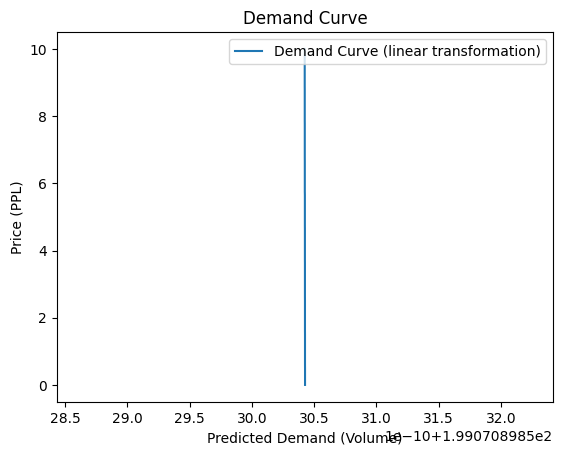

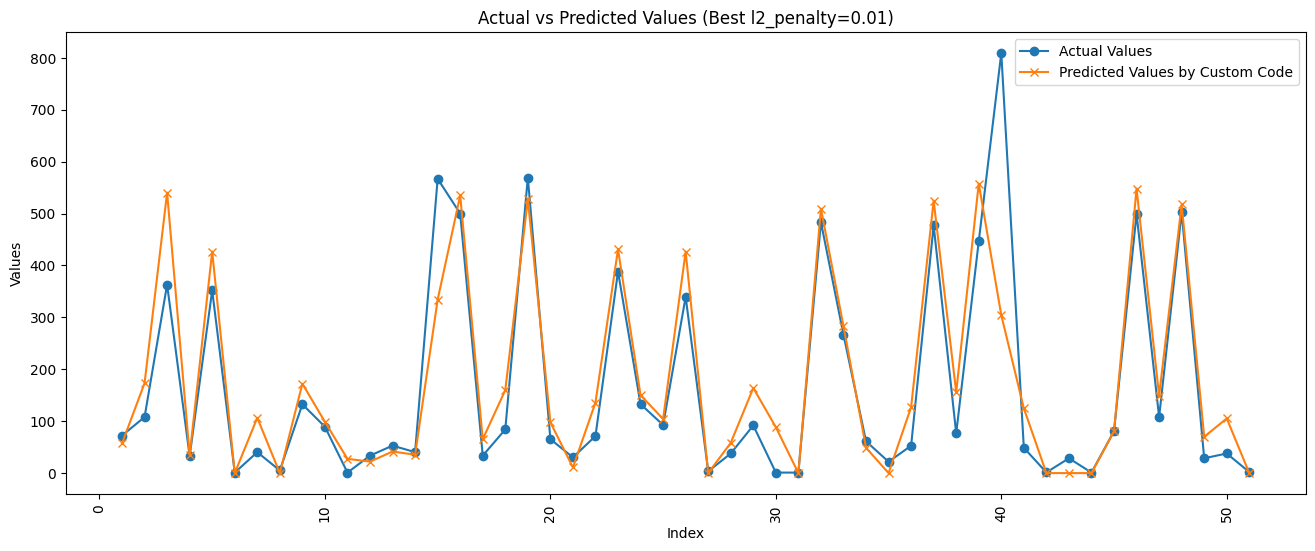

enough data points( 492   ) for combination of Channel>>> Convenience and PPG >>> Standard Multi and available brands are ['BRANSTON' 'HEINZ Standard' 'Private Label Std'] 
(492, 18) >>>>>>>>>>>>>>>>>>>>>>>>>>>
Best l2_penalty: 0.01
MAPE (Train): 19.36%
MAPE (Test): 22.31%
linear Tranformation
(19,)
[-1.07875426e-09 -3.22773296e-09 -8.10260279e+03  7.00567990e+03
 -9.99798972e-06 -9.99986449e-06 -3.62954049e+03 -1.69992905e+03
  1.44937522e+03 -3.23235521e+03 -1.71630408e+03 -7.70410775e+02
  1.66889075e+03  1.34114452e+04 -1.50769764e+04 -4.63547728e+03
 -3.93987509e+03 -1.03391510e+04]
(492, 18) (18,)
[[-0.69462461 -0.80769009 -0.28481429 ...  1.21179499  0.
   0.        ]
 [-0.69750461 -0.810419   -0.29298851 ...  1.21031767  0.
   0.        ]
 [-0.47186079  0.71343762 -0.02565212 ...  1.32606372  0.
   0.        ]
 ...
 [-0.38361817  1.20780808 -0.78814792 ...  0.          0.
   1.37132857]
 [-0.38304505  1.20434492 -0.77517314 ...  0.          0.
   1.37162256]
 [-0.38415262  1.19

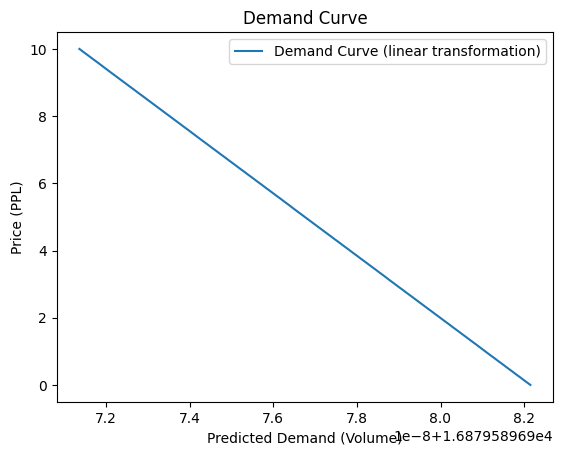

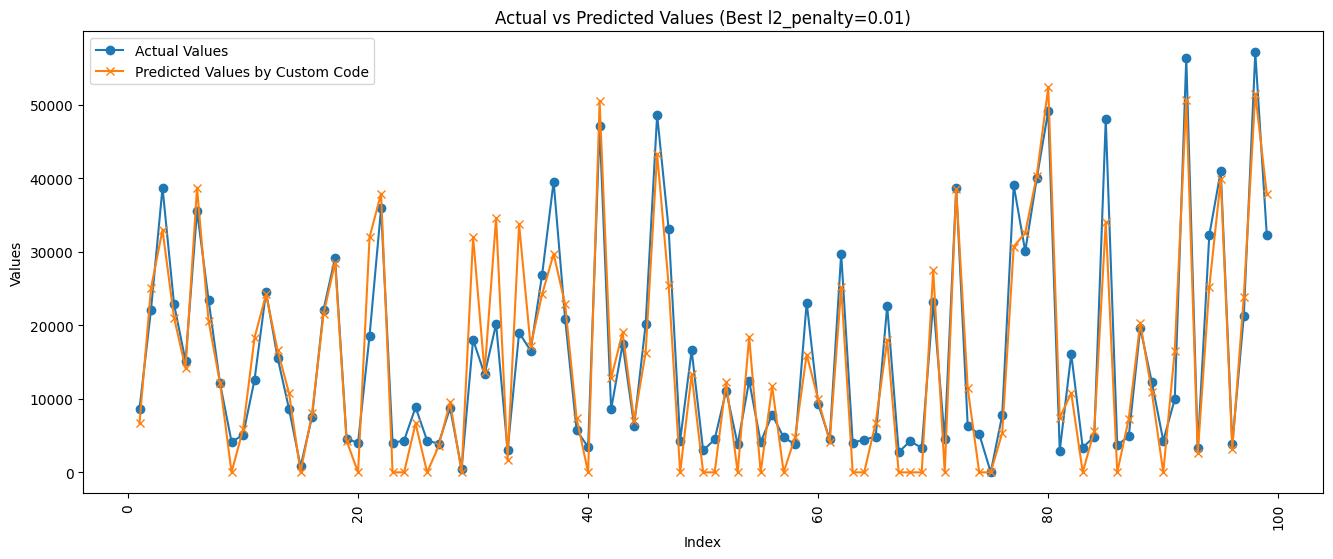

enough data points( 817   ) for combination of Channel>>> Convenience and PPG >>> Standard Single and available brands are ['BRANSTON' 'HEINZ Flavoured' 'HEINZ Standard' 'Private Label Std'
 'Restofcategory'] 
(817, 22) >>>>>>>>>>>>>>>>>>>>>>>>>>>
Best l2_penalty: 0.01
MAPE (Train): 16.80%
MAPE (Test): 17.63%
linear Tranformation
(23,)
[-8.37534842e-08 -1.73478776e-08 -5.55240335e+03  4.69457619e+03
 -9.44931446e-06 -9.98129561e-06 -1.62283160e+03 -4.46984983e+02
  1.25097420e+03  2.93594481e+03 -1.42616179e+02 -2.84657835e+03
 -7.62222711e+03 -2.71673404e+03  1.43060664e+04  3.57535357e+03
 -7.53245898e+03 -1.49949944e+03 -5.68159937e+03 -5.23452940e+02
  4.50287569e+03 -8.23613781e+03]
(817, 22) (22,)
[[-0.51335678  0.50123012  0.01854752 ...  0.          0.
   0.        ]
 [-0.51011931  0.50328734  0.01978683 ...  0.          0.
   0.        ]
 [-0.93467427  0.09936981 -0.48639207 ...  0.          0.
   0.        ]
 ...
 [-0.70253022 -0.87163938 -0.81004779 ...  0.          0.
   1.

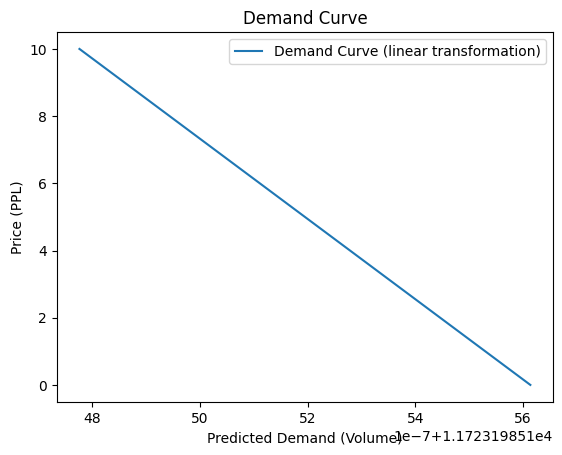

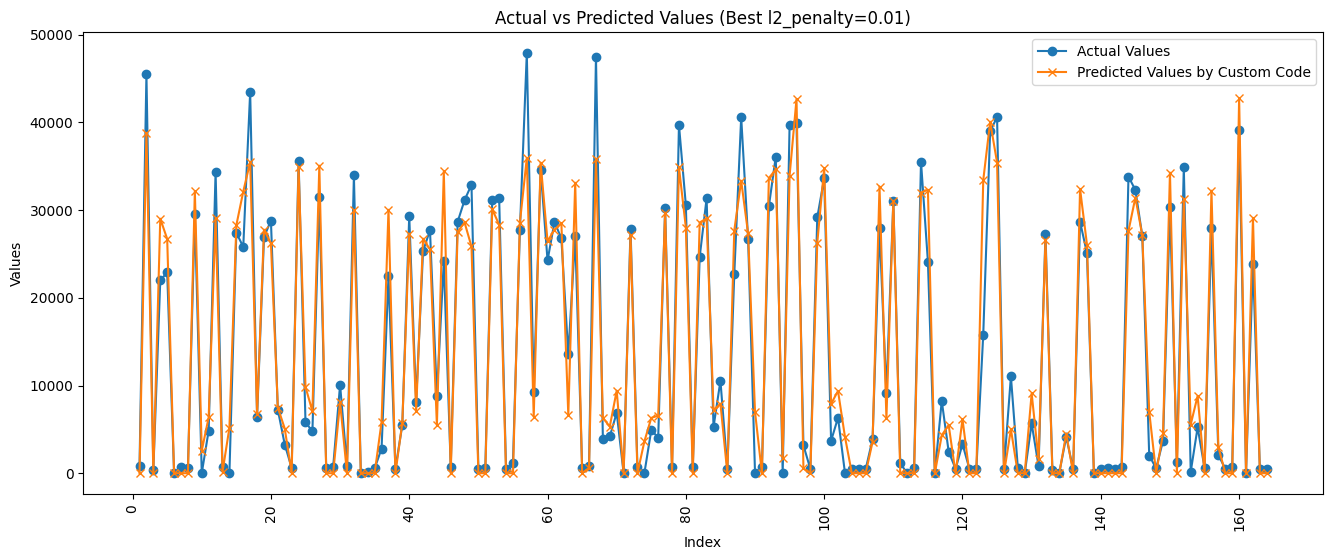

enough data points( 475   ) for combination of Channel>>> Convenience and PPG >>> Small Single and available brands are ['HEINZ Flavoured' 'HEINZ Standard' 'Private Label Std' 'Restofcategory'] 
(475, 20) >>>>>>>>>>>>>>>>>>>>>>>>>>>


KeyboardInterrupt: 

In [27]:
unique_channel=df.Channel.unique()
# unique_channel=['Supermarkets']
channel=[]
ppg_list=[]
unique_brand_list=[]
train_mape=[]
test_mape=[]
zero_demand_list=[]
for ch in unique_channel:
  df_ch=df[df['Channel']==ch]

  unique_ppg=df_ch.PPG.unique()
  # unique_ppg=['Standard Multi']
  for ppg in unique_ppg:
    df_ch_ppg=df_ch[df_ch['PPG']==ppg]
    unique_brand=df_ch_ppg.Brand.unique()


    df_ch_ppg=df_ch_ppg[['Market', 'Channel', 'Region', 'Category', 'SubCategory', 'Brand',
          'Variant', 'PackType', 'PPG', 'PackSize', 'Year',
          'Month', 'Week', 'Date', 'SalesValue', 'Volume', 'VolumeUnits', 'D1',
          'PPU', 'PPL', 'Cat_Vol_all_Chn', 'Cat_Vol_in_Chn', 'Seasonality',
          'Trend', 'Cat_Sales_in_Chn', 'Volume_sum_cann', 'D1_cann',
          'D1_Comp@Direct', 'D1_Comp@Indirect', 'PPU_cann', 'PPU_Comp@Direct',
          'PPU_Comp@Indirect', 'PPL_cann', 'PPL_Comp@Direct', 'PPL_Comp@Indirect',
          'Up_Down_Index', 'Cat_Pr_Index']]

    df_ch_ppg.dropna(inplace=True)
    df_ch_ppg.reset_index(drop=True,inplace=True)
    # df_ch_ppg=remove_outliers_iqr(df_ch_ppg)
    if len(df_ch_ppg)>30:


      print(f'enough data points( {len(df_ch_ppg)}   ) for combination of Channel>>> {ch} and PPG >>> {ppg} and available brands are {unique_brand} ')
      transform_function='linear'
      mape_train,mape_test,opt_w,zero_demand_price=Custom_ridge(df_ch_ppg, transform_function)
      # print(len(opt_w))
      # price_coef_index=1
      # price_range=[0,10]

      channel.append(ch)
      ppg_list.append(ppg)
      train_mape.append(mape_train)
      test_mape.append(mape_test)
      unique_brand_list.append(unique_brand)
      zero_demand_list.append(zero_demand_price)


    else :
      print(f'not enough data points ( {len(df_ch_ppg)}   ) for combination of Channel>>> {ch} and PPG >>> {ppg} and available brands are {unique_brand} ')

In [ ]:
result_df=pd.DataFrame({'Channel':channel,'PPG':ppg_list,'Brands':unique_brand_list,'Train_MAPE':train_mape,'Test_MAPE':test_mape})

result_df['Train_MAPE']=result_df['Train_MAPE'].round(2)
result_df['Test_MAPE']=result_df['Test_MAPE'].round(2)
result_df